# Bellabeat Case Study

### Introduction:-
This case study is the capstone project for the Google Data Analytics Professional Certificate program. The goal of this analysis is to apply the full data analysis lifecycle (Ask, Prepare, Process, Analyze, Share, Act) to a real-world business scenario for Bellabeat.
Bellabeat is a high-tech manufacturer of health-focused products for women. This analysis focuses on identifying consumer behavior trends from smart device data to inform Bellabeat’s global marketing strategy.

## 1. Ask

#### Question 1: What is the problem?
Bellabeat wants to grow in the smart device market but needs to understand how consumers are already using fitness trackers to make smarter marketing decisions.

#### Question 2: How can insights drive business decisions?
By identifying usage patterns (sleep, steps, activity), Bellabeat can target the right audience, at the right time, with the right product message.

### Objective:- 
"The goal of this analysis is to examine FitBit smart device usage data to identify trends in how consumers use fitness trackers. These insights will be applied to one Bellabeat product to provide data-driven marketing strategy recommendations to the Bellabeat executive team."


### Stakeholders to mention:
Urška Sršen — CCO, requested the analysis
Sando Mur — Co-founder, executive decision maker
Bellabeat Marketing Analytics Team — will act on findings
Sršen asks you to analyze smart device usage data in order to gain insight into how consumers use non-Bellabeat smart devices. She then wants you to select one Bellabeat product to apply these insights to in your presentation. These questions will guide your analysis: 1. What are some trends in smart device usage? 2. How could these trends apply to Bellabeat customers? 3. How could these trends help influence Bellabeat marketing strategy?

### Product Focus
For this analysis, I decided to focus on the Bellabeat App.
The reason I chose the app is that it sits at the center of everything Bellabeat does. It connects to the Leaf, the Time watch, and the Spring bottle  so any insights I find are relevant across the whole product line, not just one device. The app also tracks a lot of the same things the FitBit data covers  activity, sleep, and stress which makes it a natural fit for this kind of analysis.
Problem Statement
Bellabeat is doing well, but there's a bigger opportunity out there in the global smart device market. The challenge is figuring out how to reach more women and keep them engaged with the product long term. To do that, we first need to understand how people are actually using fitness trackers in their daily lives — what they track, when they're most active, where they fall short of their health goals. That understanding is what this analysis is trying to build, and it's what will guide the marketing recommendations at the end.



---

## 2. Prepare

### About the Data

For this analysis I used the FitBit Fitness Tracker Data, which is 
freely available on Kaggle. The data was collected from 30 FitBit 
users who agreed to share their personal tracker information over 
roughly two months, somewhere between March and May 2016.

The dataset comes in two separate folders based on date range. I 
mainly worked with two files out of the whole collection:

- **dailyActivity_merged.csv** — this one has everything in one place, 
steps taken, calories burned, distance covered, and how much time 
was spent being active versus sitting still
- **sleepDay_merged.csv** — this tracks how many hours each user 
slept and how many times they woke up during the night

### Data Credibility — ROCCC Check

Before jumping into the analysis I wanted to be honest about what 
this data can and can't tell us. Here's how it holds up:

- **Reliable** — not really. 30 people is a very small group to draw 
conclusions from, so the findings won't apply to everyone
- **Original** — yes, the data came straight from the FitBit devices 
themselves, which is a good sign
- **Comprehensive** — somewhat. It covers the basics like steps, 
calories and sleep, but it misses things like hydration and stress 
which are actually central to what Bellabeat tracks
- **Current** — unfortunately no. 2016 was almost 10 years ago and 
the way people use wearables has changed a lot since then
- **Cited** — yes, it's publicly available on Kaggle under a CC0 
license so there are no legal concerns using it

### Limitations

Honestly, before I get into the findings I want to be upfront about some of the issues I noticed with this data.

- The biggest one is the sample size. Thirty people is really not a lot. It's hard to look at 30 users and confidently say "this is how everyone behaves" — so take the patterns we find here as directional rather than definitive.

- The data is also pretty old at this point. It was collected back in 2016, which is nearly a decade ago. The way people use wearables today is pretty different from how they used them back then, so some of what we see here might not fully reflect current behavior.
There's also no way to know if any of these 30 users are actually women. That's a real gap considering Bellabeat's entire product line is built for women. Ideally we'd be analyzing data from Bellabeat's own users, but this is what we have to work with right now.

- On top of that, not everyone logged their sleep every night, so there are some holes in the sleep data. And there's zero demographic information — no age, no location, nothing about lifestyle or health goals.

  
That said, I don't think these limitations make the analysis useless. Even a small dataset can point you in the right direction, and the patterns we find here are still worth paying attention to. It just means we should be a little careful about how strongly we state our conclusions.

In [135]:
import os

# This shows you all available files in the dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitaba

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load activity data
df_activity = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')

# Load sleep data
df_sleep = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')

print("Activity data loaded!", df_activity.shape)
print("Sleep data loaded!", df_sleep.shape)
df_activity.head()

Activity data loaded! (940, 15)
Sleep data loaded! (413, 5)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


---

## 3. Process

### What tool am I using and why?
I went with Python for this one. Honestly it just makes everything easier cleaning messy data, running calculations, building charts that actually look good. I'm working inside a Kaggle notebook which means the dataset is already attached and I don't have to deal with uploading files or managing folders on my computer.
For libraries I kept it simple:

#### Pandas — this is the main one, used for basically everything from loading the files to cleaning and reshaping the data
#### Matplotlib — for building the charts and graphs
#### Seaborn — works on top of Matplotlib and makes the visuals look a lot cleaner with less effort

### Cleaning Steps
Before jumping into the actual analysis I spent some time getting the data into a usable state. Here's what I went through:
- First I just looked at the shape of both datasets to understand how much data I was actually working with how many rows, how many columns, that kind of thing.
- Then I checked the column names because sometimes they're messy or hard to read, and I wanted to know exactly what information was available before doing anything else.
- After that I checked for missing values. Some columns had gaps and I needed to know where before drawing any conclusions from the numbers.
- I also checked for duplicate rows. Sleep data in particular had some duplicates which I removed so they wouldn't skew the results.
- The date columns were stored as plain text which Python doesn't recognize as dates by default, so I converted those into a proper datetime format so I could do time-based analysis later.
- I then renamed all the columns to lowercase just to keep things consistent and easier to type when writing code.
- Finally I merged the activity and sleep datasets together using the user ID and date as the common link between them. This gave me one combined dataset to work with for the rest of the analysis.

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use SAME date range folder for both files
df_activity = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')

df_sleep = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')

print("Activity data loaded!", df_activity.shape)
print("Sleep data loaded!", df_sleep.shape)

Activity data loaded! (940, 15)
Sleep data loaded! (413, 5)


In [138]:
# ── PROCESS: Explore the Data ───────────────────────────
# Step 1 - Check shape
print("-" * 50)
print("DATASET OVERVIEW")
print("-" * 50)
print(f"Activity data: {df_activity.shape[0]} rows, {df_activity.shape[1]} columns")
print(f"Sleep data:    {df_sleep.shape[0]} rows, {df_sleep.shape[1]} columns")

# Step 2 - Check column names
print("\n" + "-" * 50)
print("ACTIVITY COLUMNS")
print("-" * 50)
for col in df_activity.columns:
    print(f"  • {col}")

print("\n" + "-" * 50)
print("SLEEP COLUMNS")
print("-" * 50)
for col in df_sleep.columns:
    print(f"  • {col}")

--------------------------------------------------
DATASET OVERVIEW
--------------------------------------------------
Activity data: 940 rows, 15 columns
Sleep data:    413 rows, 5 columns

--------------------------------------------------
ACTIVITY COLUMNS
--------------------------------------------------
  • Id
  • ActivityDate
  • TotalSteps
  • TotalDistance
  • TrackerDistance
  • LoggedActivitiesDistance
  • VeryActiveDistance
  • ModeratelyActiveDistance
  • LightActiveDistance
  • SedentaryActiveDistance
  • VeryActiveMinutes
  • FairlyActiveMinutes
  • LightlyActiveMinutes
  • SedentaryMinutes
  • Calories

--------------------------------------------------
SLEEP COLUMNS
--------------------------------------------------
  • Id
  • SleepDay
  • TotalSleepRecords
  • TotalMinutesAsleep
  • TotalTimeInBed


In [139]:
# Step 3 - Check for missing values

print("-" * 50)
print("MISSING VALUES CHECK")
print("-" * 50)

activity_nulls = df_activity.isnull().sum().sum()
sleep_nulls = df_sleep.isnull().sum().sum()

print(f"  • Activity data:  {activity_nulls} missing values")
print(f"  • Sleep data:     {sleep_nulls} missing values")

if activity_nulls == 0 and sleep_nulls == 0:
    print("\n  ✓ No missing values found — data looks clean!")

--------------------------------------------------
MISSING VALUES CHECK
--------------------------------------------------
  • Activity data:  0 missing values
  • Sleep data:     0 missing values

  ✓ No missing values found — data looks clean!


In [140]:
# Step 4 - Check for duplicates

print("-" * 50)
print("DUPLICATES CHECK")
print("-" * 50)

act_dups = df_activity.duplicated().sum()
sleep_dups = df_sleep.duplicated().sum()

print(f"  • Activity data:  {act_dups} duplicate rows")
print(f"  • Sleep data:     {sleep_dups} duplicate rows")

# Remove duplicates
df_activity = df_activity.drop_duplicates()
df_sleep = df_sleep.drop_duplicates()

print(f"\n  ✓ Duplicates removed!")
print(f"  • Activity rows remaining: {df_activity.shape[0]}")
print(f"  • Sleep rows remaining:    {df_sleep.shape[0]}")

--------------------------------------------------
DUPLICATES CHECK
--------------------------------------------------
  • Activity data:  0 duplicate rows
  • Sleep data:     3 duplicate rows

  ✓ Duplicates removed!
  • Activity rows remaining: 940
  • Sleep rows remaining:    410


In [141]:
# Step 5 - Fix date columns

df_activity['ActivityDate'] = pd.to_datetime(
    df_activity['ActivityDate'], format='mixed')

df_sleep['SleepDay'] = pd.to_datetime(
    df_sleep['SleepDay'], format='mixed')

print("-" * 50)
print("DATE FORMAT CHECK")
print("-" * 50)
print(f"  • ActivityDate format:  {df_activity['ActivityDate'].dtype}")
print(f"  • SleepDay format:      {df_sleep['SleepDay'].dtype}")
print("\n  ✓ Date columns converted successfully!")

--------------------------------------------------
DATE FORMAT CHECK
--------------------------------------------------
  • ActivityDate format:  datetime64[ns]
  • SleepDay format:      datetime64[ns]

  ✓ Date columns converted successfully!


In [142]:
# Step 6 - Rename columns to lowercase

df_activity.columns = df_activity.columns.str.lower()
df_sleep.columns = df_sleep.columns.str.lower()

print("-" * 50)
print("COLUMN NAMES — AFTER CLEANING")
print("-" * 50)

print("\n  Activity columns:")
for col in df_activity.columns:
    print(f"    • {col}")

print("\n  Sleep columns:")
for col in df_sleep.columns:
    print(f"    • {col}")

print("\n  ✓ All columns renamed to lowercase!")

--------------------------------------------------
COLUMN NAMES — AFTER CLEANING
--------------------------------------------------

  Activity columns:
    • id
    • activitydate
    • totalsteps
    • totaldistance
    • trackerdistance
    • loggedactivitiesdistance
    • veryactivedistance
    • moderatelyactivedistance
    • lightactivedistance
    • sedentaryactivedistance
    • veryactiveminutes
    • fairlyactiveminutes
    • lightlyactiveminutes
    • sedentaryminutes
    • calories

  Sleep columns:
    • id
    • sleepday
    • totalsleeprecords
    • totalminutesasleep
    • totaltimeinbed

  ✓ All columns renamed to lowercase!


In [143]:
# Step 7 - Merge activity and sleep data

df_merged = pd.merge(df_activity, df_sleep,
                     left_on=['id', 'activitydate'],
                     right_on=['id', 'sleepday'],
                     how='inner')
df_merged['activitydate'] = pd.to_datetime(df_merged['activitydate'])
df_merged['day_of_week'] = df_merged['activitydate'].dt.day_name()

print("-" * 50)
print("MERGE SUMMARY")
print("-" * 50)
print(f"  Activity rows:    {df_activity.shape[0]}")
print(f"  Sleep rows:       {df_sleep.shape[0]}")
print(f"  Merged rows:      {df_merged.shape[0]}")
print(f"  Merged columns:   {df_merged.shape[1]}")
print("  Datasets merged successfully!")
df_merged.head()

--------------------------------------------------
MERGE SUMMARY
--------------------------------------------------
  Activity rows:    940
  Sleep rows:       410
  Merged rows:      410
  Merged columns:   20
  Datasets merged successfully!


,id,activitydate,totalsteps,totaldistance,trackerdistance,loggedactivitiesdistance,veryactivedistance,moderatelyactivedistance,lightactivedistance,sedentaryactivedistance,veryactiveminutes,fairlyactiveminutes,lightlyactiveminutes,sedentaryminutes,calories,sleepday,totalsleeprecords,totalminutesasleep,totaltimeinbed,day_of_week
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1,327,346,Tuesday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,2,384,407,Wednesday
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,1,412,442,Friday
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,2,340,367,Saturday
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,2016-04-17,1,700,712,Sunday


## 4. Analyse

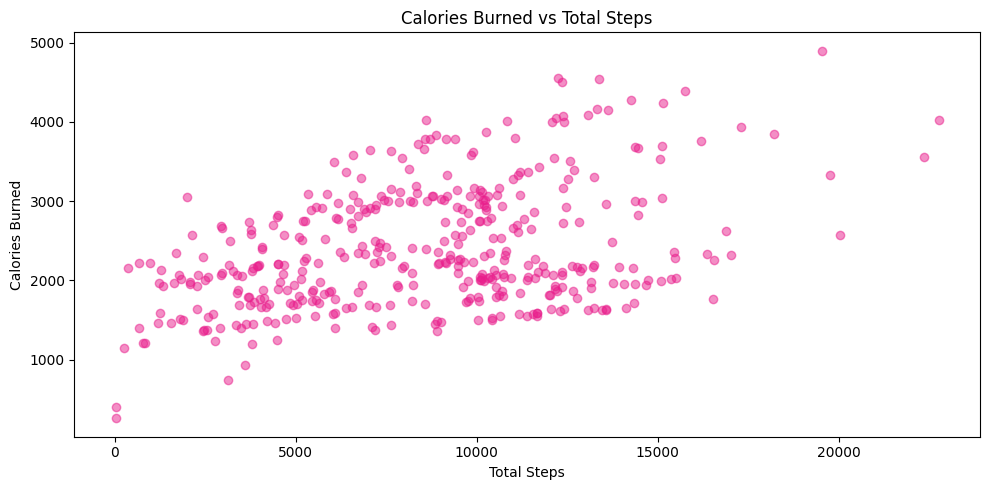

In [144]:
plt.figure(figsize=(10,5))
plt.scatter(df_merged['totalsteps'], df_merged['calories'], alpha=0.5, color='#E91E8C')
plt.title('Calories Burned vs Total Steps')
plt.xlabel('Total Steps')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.show()

### What the chart tells us:
There's a pretty clear trend here  the more steps someone takes, the more calories they burn. Not exactly shocking, but it's good to see the data confirm it.
Most people are clustered around 5,000–10,000 steps and 2,000–3,000 calories, which is kind of the "average user" zone.
But the interesting part is the spread. At the same step count say 10,000 steps some people are burning 2,000 calories while others are burning 4,000+. That gap tells us that steps alone don't tell the whole story. Things like workout intensity, body weight, and metabolism all play a role.
There are also a few people hitting 15,000–20,000 steps these are your highly active users, and they're burning significantly more.

### What Bellabeat can do with this:
Steps are a great motivator, but Bellabeat could go deeper — reminding users that how they move matters just as much as how much they move. A short intense workout can burn just as many calories as a long casual walk. That's a message that fits really well with Bellabeat's focus on holistic wellness.


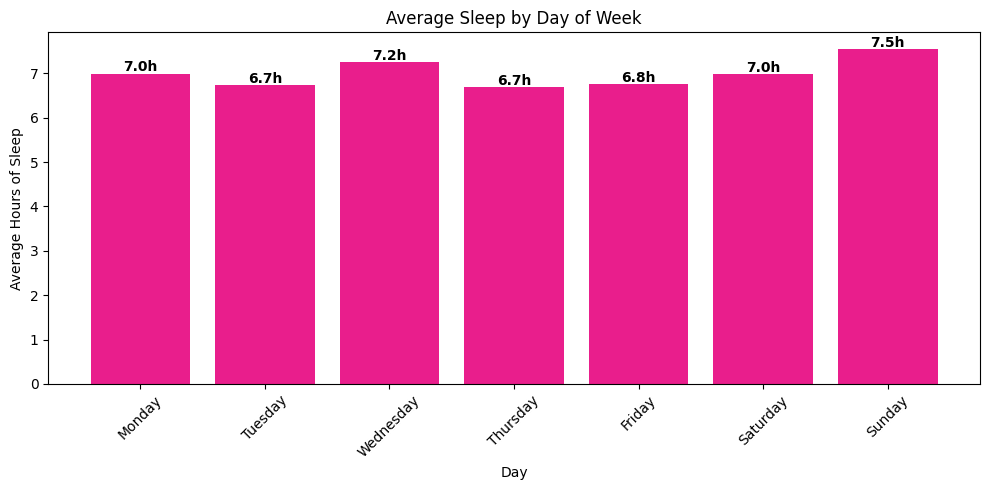

In [145]:
avg_sleep = df_merged.groupby('day_of_week')['totalminutesasleep'].mean().reindex(day_order)

plt.figure(figsize=(10,5))
plt.bar(avg_sleep.index, avg_sleep.values / 60, color='#E91E8C')
plt.title('Average Sleep by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Hours of Sleep')
plt.xticks(rotation=45)

# Add numbers on top of each bar
for i, v in enumerate(avg_sleep.values / 60):
    plt.text(i, v + 0.05, f'{v:.1f}h', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### What the chart tells us:
First thing that stands out  nobody in this dataset is getting the recommended 8 hours of sleep. The highest is Sunday at 7.5h and the lowest is Tuesday and Thursday at just 6.7h. That's a pattern worth paying attention to.
It makes total sense that Sunday is the best sleep night  no alarm, no rush, people just naturally sleep in. And Wednesday night into Thursday being the lowest tracks too  mid-week stress, late nights, the week catching up on you.
What's interesting is Wednesday actually shows 7.2h which is higher than you'd expect. People might be compensating for a rough Tuesday by going to bed earlier that night.
The overall range isn't huge we're talking 6.7h to 7.5h  so sleep habits are fairly consistent across the week, just never quite hitting that sweet spot.

### What Bellabeat can do with this:
This is actually a big opportunity. Since users are consistently sleeping just under the recommended amount, Bellabeat's app could introduce a "wind down" reminder in the evenings  especially on Tuesday and Thursday nights when sleep tends to suffer most. Small nudges like "time to put the phone down" or a bedtime goal tracker could genuinely help users and keep them engaged with the app daily.


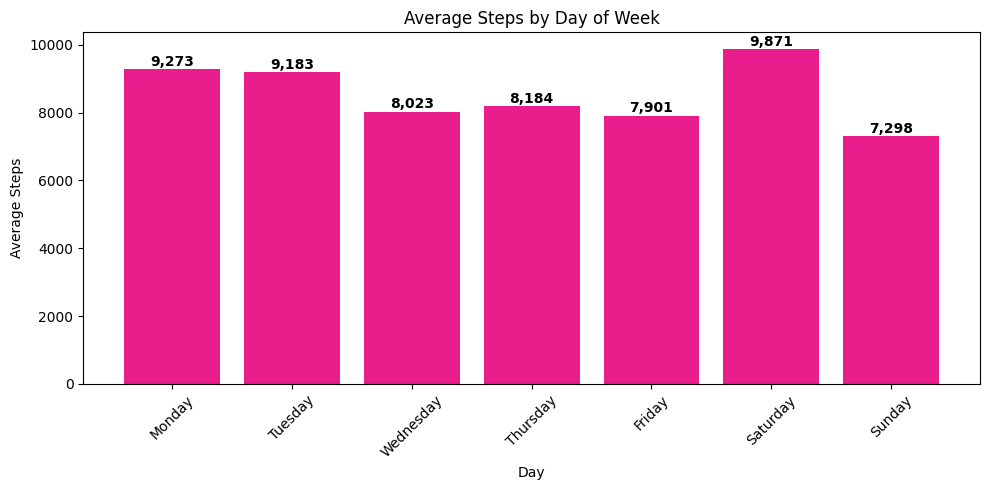

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Average steps by day of week
df_merged['activitydate'] = pd.to_datetime(df_merged['activitydate'])
df_merged['day_of_week'] = df_merged['activitydate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_steps = df_merged.groupby('day_of_week')['totalsteps'].mean().reindex(day_order)

plt.figure(figsize=(10,5))
plt.bar(avg_steps.index, avg_steps.values, color='#E91E8C')
plt.title('Average Steps by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Steps')
plt.xticks(rotation=45)

# Add numbers on top of each bar
for i, v in enumerate(avg_steps.values):
    plt.text(i, v + 100, f'{v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### What the chart tells us:
Saturday is the clear winner at 9,871 steps almost hitting that 10,000 step goal that fitness trackers love to push. People are out, active, living their weekend.
Monday and Tuesday are surprisingly strong at 9,273 and 9,183 steps. That "new week energy" is real people start the week motivated and it shows.
Then comes the mid-week crash. Steps drop to 8,023 on Wednesday and barely recover through Thursday (8,184) and Friday (7,901). The week is grinding people down and it shows up directly in how much they move.
Sunday is the laziest day at just 7,298 steps  nearly 2,600 fewer steps than Saturday. People are resting, recovering, and probably not leaving the couch much.
Worth noting none of the days actually hit the commonly recommended 10,000 steps, even on the most active day (Saturday falls just short at 9,871). So there's room for improvement across the board.

### What Bellabeat can do with this:
The Wednesday–Friday slump is a clear window for Bellabeat to step in with gentle step challenges or reminders. Even a small nudge like "you're 2,000 steps away from your goal" on a Friday afternoon could make a real difference. And for Sundays, a light "get moving" notification could help users close their week strong instead of ending on their lowest day.

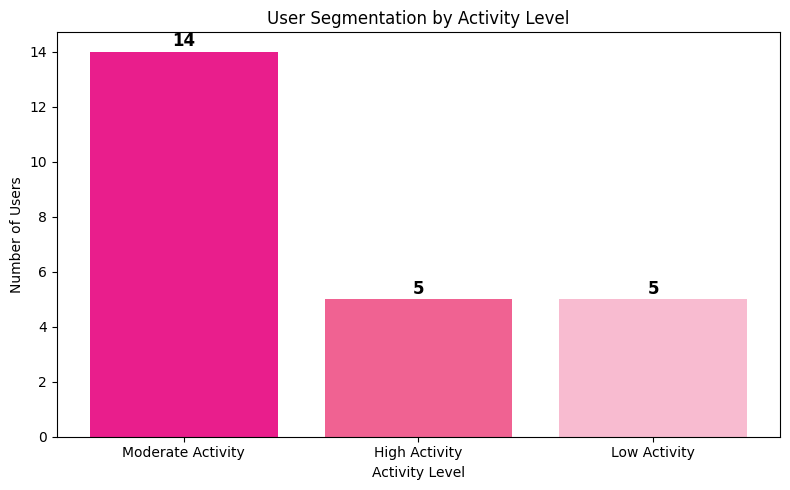

In [147]:
# User Segmentation by Average Daily Steps
avg_steps_user = df_merged.groupby('id')['totalsteps'].mean()

def segment(steps):
    if steps < 5000:
        return 'Low Activity'
    elif steps < 10000:
        return 'Moderate Activity'
    else:
        return 'High Activity'

segments = avg_steps_user.apply(segment).value_counts()

plt.figure(figsize=(8,5))
colors = ['#E91E8C', '#F06292', '#F8BBD0']
plt.bar(segments.index, segments.values, color=colors)
plt.title('User Segmentation by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Number of Users')

# Add numbers on top
for i, v in enumerate(segments.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### What the chart tells us:
Out of 24 users, the majority 14 people fall into the Moderate Activity category, meaning they average between 5,000–10,000 steps a day. These are your everyday users, not couch potatoes but not gym rats either. Just regular people trying to stay somewhat active.
Then you've got an even split 5 High Activity and 5 Low Activity users on either end. The high activity folks are consistently hitting over 10,000 steps daily, while the low activity group is struggling to even reach 5,000.
So basically more than half the user base is in the middle which is actually the most interesting group for Bellabeat because they're close to being highly active, they just need a little push.

### What Bellabeat can do with this:
The moderate activity group is the biggest opportunity. These users are already engaged enough to wear a tracker daily but haven't quite built a strong fitness habit yet. Bellabeat could target them specifically with personalized step goals something like "you averaged 7,500 steps last week, let's try for 8,500 this week"  small, achievable targets that nudge them toward the high activity zone without feeling overwhelming.
For the low activity group, the focus should be on building basic habits short walk reminders, celebrating small wins, keeping it encouraging rather than pushy.


## Act
### Recommendations for Bellabeat
Based on the analysis of FitBit user data, here are actionable recommendations for Bellabeat to better serve their users:

#### 1. Smart Sleep Reminders
Nobody in this dataset is hitting the recommended 8 hours of sleep, and Tuesday and Thursday nights are consistently the worst. Bellabeat should introduce targeted bedtime reminders on these specific nights — not a generic daily notification but a smart, pattern-based nudge that says "hey, you tend to sleep less tonight, let's fix that."
#### 2. Mid-Week Motivation Push
Activity drops noticeably from Wednesday through Friday. Bellabeat could address this with a mid-week challenge or motivational notification on Wednesday afternoons when energy and steps start declining. Something small and achievable — not "hit 10,000 steps" but "you're halfway through the week, let's keep moving."
#### 3. Target the Moderate Activity Group
More than half the users (14 out of 24) fall in the moderate activity category — averaging 5,000 to 10,000 steps daily. These users are close to being highly active, they just need a small push. Bellabeat should focus marketing and in-app features on this group with personalised micro-goals rather than overwhelming targets.
#### 4. Go Beyond Step Counting
The steps vs calories analysis shows that two people can take the same number of steps and burn very different amounts of calories. This tells us steps alone don't capture the full picture. Bellabeat should emphasise intensity tracking alongside steps to give users a more complete and accurate view of their activity.